##Binary Classification
Context:
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base. One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering - Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information. The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being. However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('Travel.csv')
df

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,204883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0
4884,204884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Single,3.0,1,3,1,2.0,Executive,21212.0
4885,204885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,204886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Single,3.0,0,5,0,2.0,Executive,20289.0


Data Cleaning

In [ ]:
#Removing Customer is--not needed

df.drop('CustomerID', axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ProdTaken                 4888 non-null   int64  
 1   Age                       4662 non-null   float64
 2   TypeofContact             4863 non-null   object 
 3   CityTier                  4888 non-null   int64  
 4   DurationOfPitch           4637 non-null   float64
 5   Occupation                4888 non-null   object 
 6   Gender                    4888 non-null   object 
 7   NumberOfPersonVisiting    4888 non-null   int64  
 8   NumberOfFollowups         4843 non-null   float64
 9   ProductPitched            4888 non-null   object 
 10  PreferredPropertyStar     4862 non-null   float64
 11  MaritalStatus             4888 non-null   object 
 12  NumberOfTrips             4748 non-null   float64
 13  Passport                  4888 non-null   int64  
 14  PitchSat

In [ ]:
df.isnull().sum()

,0
ProdTaken,0
Age,226
TypeofContact,25
CityTier,0
DurationOfPitch,251
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,45
ProductPitched,0


In [ ]:
#Handling Missing Values
#Replacing null values in categorical features with mode
#nd median in numerical features


df['Age'].fillna(df['Age'].median(), inplace=True)
df['DurationOfPitch'].fillna(df['DurationOfPitch'].median(), inplace=True)
df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].mode()[0], inplace=True)
df['PreferredPropertyStar'].fillna(df['PreferredPropertyStar'].mode()[0], inplace=True)
df['TypeofContact'].fillna(df['TypeofContact'].mode()[0], inplace=True)
df['NumberOfTrips'].fillna(df['NumberOfTrips'].median(), inplace=True)
df['NumberOfChildrenVisiting'].fillna(df['NumberOfChildrenVisiting'].mode()[0], inplace=True)
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)

In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,2916
Female,1817
Fe Male,155


In [ ]:
df['MaritalStatus'].value_counts()

,count
MaritalStatus,
Married,2340
Divorced,950
Single,916
Unmarried,682


In [ ]:
df['Gender'].replace('Fe Male','Female',inplace=True)

In [ ]:
df['MaritalStatus'].replace('Single','Unmarried',inplace=True)

In [ ]:
df['MaritalStatus'].value_counts()

,count
MaritalStatus,
Married,2340
Unmarried,1598
Divorced,950


In [ ]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [ ]:
#Combining NumberOfPersonVisiting and NumberOfChildrenVisiting into one column - TotalVisiting

df['TotalVisiting'] = df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']
df.head(2)

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0,5.0


In [ ]:
df.drop(['NumberOfPersonVisiting','NumberOfChildrenVisiting'], axis=1, inplace=True)
df.head(2)

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0


In [ ]:
#handling duplicates

df.drop_duplicates(inplace=True)


In [ ]:
#Splitting Independent and dependent features

X = df.drop('ProdTaken', axis=1)
y = df['ProdTaken']

In [ ]:
#Train test split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Finding numerical and categorical features

num_features = X.select_dtypes(include='number').columns
cat_features = X.select_dtypes(exclude='number').columns

In [ ]:
cat_features,num_features

(Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
        'MaritalStatus', 'Designation'],
       dtype='object'),
 Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups',
        'PreferredPropertyStar', 'NumberOfTrips', 'Passport',
        'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisiting'],
       dtype='object'))

In [ ]:
#OneHotEncoding and Standardization

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(transformers=[('encoder',OneHotEncoder(drop='first'),cat_features),
                                     ('scaler',StandardScaler(),num_features)],remainder='passthrough')

In [ ]:
ct

ColumnTransformer(remainder='passthrough',
                  transformers=[('encoder', OneHotEncoder(drop='first'),
                                 Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')),
                                ('scaler', StandardScaler(),
                                 Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups',
       'PreferredPropertyStar', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisiting'],
      dtype='object'))])

In [ ]:
#Applying CoulumnTransformer transformations on train and test data

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

Model selection and Model Training

In [ ]:
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score,roc_auc_score


In [ ]:
#Defining a function for Performance evaluation of a model

def evaluate_model(true,predicted):
  accuracy = accuracy_score(true,predicted)
  precision = precision_score(true,predicted)
  recall = recall_score(true,predicted)
  f1 = f1_score(true,predicted)
  roc_auc = roc_auc_score(true,predicted)

  return accuracy,precision,recall,f1,roc_auc

In [ ]:
#Dictionary of models

models = {
    'XgBoost Classifier':XGBClassifier(),
    'Decision Tree':DecisionTreeClassifier(),
    'Random Forest':RandomForestClassifier(),
    'Gradient Boost':GradientBoostingClassifier(),
    'AdaBoost':AdaBoostClassifier()
}

In [ ]:
#Training over different model and evaluating its performance

for name,model in models.items():
  model.fit(X_train,y_train)

  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)

  print(name)
  print("Performance of Training data:")
  accuracy1,precision1,recall1,f1_train,roc_auc1 = evaluate_model(y_train,y_train_pred)
  print(f'Accuracy: {accuracy1:.2f}')
  print(f'Precision: {precision1:.2f}')
  print(f'Recall: {recall1:.2f}')
  print(f'F1 Score: {f1_train:.2f}')
  print(f'ROC AUC Score: {roc_auc1:.2f}')

  print("Performance of Testing data:")
  accuracy2,precision2,recall2,f1_test,roc_auc2 = evaluate_model(y_test,y_test_pred)
  print(f'Accuracy: {accuracy2:.2f}')
  print(f'Precision: {precision2:.2f}')
  print(f'Recall: {recall2:.2f}')
  print(f'F1 Score: {f1_test:.2f}')
  print(f'ROC AUC Score: {roc_auc2:.2f}')
  print("\n")

XgBoost Classifier
Performance of Training data:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00
ROC AUC Score: 1.00
Performance of Testing data:
Accuracy: 0.95
Precision: 0.92
Recall: 0.78
F1 Score: 0.85
ROC AUC Score: 0.88


Decision Tree
Performance of Training data:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00
ROC AUC Score: 1.00
Performance of Testing data:
Accuracy: 0.92
Precision: 0.78
Recall: 0.80
F1 Score: 0.79
ROC AUC Score: 0.87


Random Forest
Performance of Training data:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00
ROC AUC Score: 1.00
Performance of Testing data:
Accuracy: 0.94
Precision: 0.93
Recall: 0.71
F1 Score: 0.81
ROC AUC Score: 0.85


Gradient Boost
Performance of Training data:
Accuracy: 0.89
Precision: 0.85
Recall: 0.47
F1 Score: 0.61
ROC AUC Score: 0.73
Performance of Testing data:
Accuracy: 0.87
Precision: 0.79
Recall: 0.42
F1 Score: 0.55
ROC AUC Score: 0.70


AdaBoost
Performance of Training data:
Accuracy: 0.85
Precisio

HyperParameter Tuning with Random Forest Classifier and XgBoost Classifier

In [ ]:
rf_params = {
    'max_depth':[5,8,15,None,10],
    'n_estimators':[100,200,500,1000],
    'max_features':['auto',5,7,8],
    'min_samples_split':[2,8,15,20]
}

xgb_params = {
    'learning_rate':[0.1,0.01],
    'max_depth':[5,8,12,20,30],
    'n_estimators':[100,200,300],
    'colsample_bytree':[0.5,0.8,1,0.3,0.4]
}

In [ ]:
#RandomSearchCV
from sklearn.model_selection import RandomizedSearchCV

randomcv = [
    ('RF',RandomForestClassifier,rf_params),
    ('XGB',XGBClassifier,xgb_params)
]

In [ ]:
model_params = {}
for name,model,params in randomcv:
  random = RandomizedSearchCV(model(),param_distributions=params,n_iter=100,cv=3,verbose=2,n_jobs=-1)
  random.fit(X_train,y_train)

  model_params[name] = random.best_params_

for name in model_params:
  print(f'Best Parameters for {name} are : {model_params[name]}')

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Parameters for RF are : {'n_estimators': 1000, 'min_samples_split': 2, 'max_features': 7, 'max_depth': 15}
Best Parameters for XGB are : {'n_estimators': 200, 'max_depth': 30, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [ ]:
models = {
    'Random Forest':RandomForestClassifier(max_depth=15, max_features=7, min_samples_split=2, n_estimators=1000),
    'XgBoost':XGBClassifier(n_estimators=200, max_depth=30,learning_rate=0.1,colsample_bytree=0.8)
}
for name,model in models.items():
    model.fit(X_train,y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print(name)
    print("Performance of Training data:")
    accuracy1,precision1,recall1,f1_train,roc_auc1 = evaluate_model(y_train,y_train_pred)
    print(f'Accuracy: {accuracy1:.2f}')
    print(f'Precision: {precision1:.2f}')
    print(f'Recall: {recall1:.2f}')
    print(f'F1 Score: {f1_train:.2f}')
    print(f'ROC AUC Score: {roc_auc1:.2f}')

    print("Performance of Testing data:")
    accuracy2,precision2,recall2,f1_test,roc_auc2 = evaluate_model(y_test,y_test_pred)
    print(f'Accuracy: {accuracy2:.2f}')
    print(f'Precision: {precision2:.2f}')
    print(f'Recall: {recall2:.2f}')
    print(f'F1 Score: {f1_test:.2f}')
    print(f'ROC AUC Score: {roc_auc2:.2f}')
    print("\n")

Random Forest
Performance of Training data:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00
ROC AUC Score: 1.00
Performance of Testing data:
Accuracy: 0.94
Precision: 0.95
Recall: 0.71
F1 Score: 0.81
ROC AUC Score: 0.85


XgBoost
Performance of Training data:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00
ROC AUC Score: 1.00
Performance of Testing data:
Accuracy: 0.95
Precision: 0.95
Recall: 0.81
F1 Score: 0.87
ROC AUC Score: 0.90




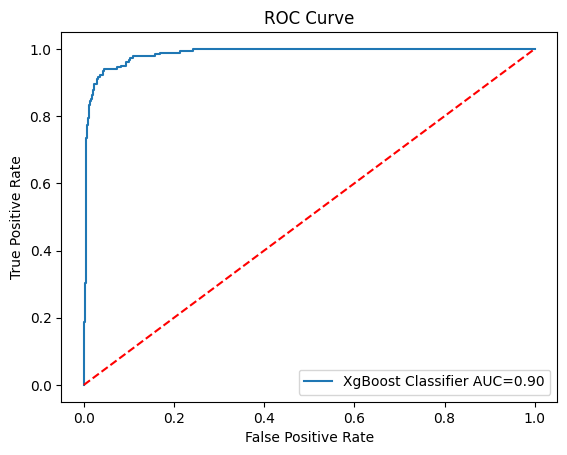

In [ ]:
#ROC AUC curve

from sklearn.metrics import roc_curve
auc_models = [
    {
        'label':'XgBoost Classifier',
        'model':XGBClassifier(n_estimators=200, max_depth=30,learning_rate=0.1,colsample_bytree=0.8),
        'auc':0.90
    }
]

for algo in auc_models:
  model = algo['model']
  model.fit(X_train,y_train)
  y_pred_prob = model.predict_proba(X_test)[:,1]

  fpr,tpr,threshold = roc_curve(y_test,y_pred_prob)
  plt.plot(fpr,tpr,label=f'{algo["label"]} AUC={algo["auc"]:.2f}')

plt.plot([0,1],[0,1],'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

Thus, Area under Curve is 90%